In [63]:
from google.colab import userdata
github_token = userdata.get("GITHUB_TOKEN")

!git config --global user.email "roshinsthomas@gmail.com"
!git config --global user.name 'roshinsthomas'

In [64]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

#load datasets
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

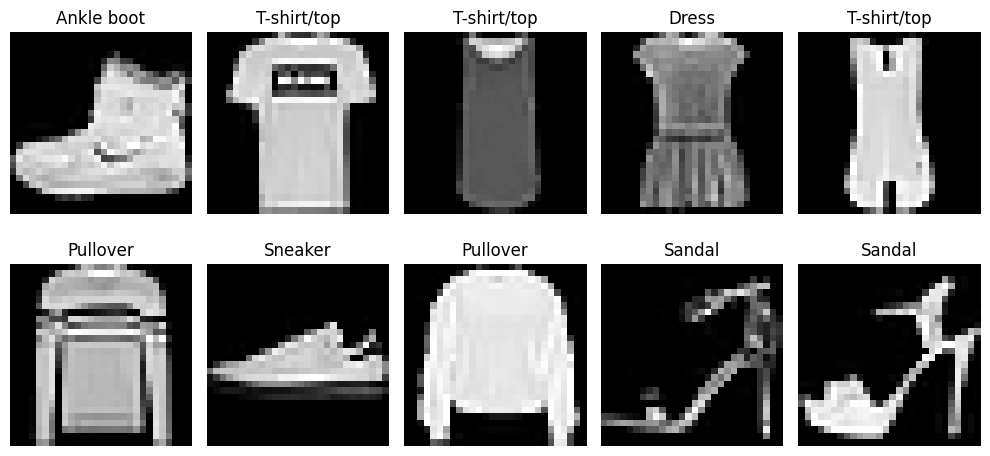

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(10):
  plt.subplot(2,5, i +1)
  plt.imshow(x_train[i], cmap = 'gray')
  plt.title(class_names[y_train[i]])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [66]:
# Check the number and dimensions of images and labels
print("X Train:", np.unique(y_train))
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

# Inspect how pixel values are stored
print("Pixel data type:", x_train.dtype)
print("Pixel range:", x_train.min(), "to", x_train.max())

X Train: [0 1 2 3 4 5 6 7 8 9]
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel data type: uint8
Pixel range: 0 to 255


In [67]:
# Find each category number and count its occurrences
labels, counts = np.unique(y_train, return_counts=True)

for label, count in zip(labels, counts):
    print(f"{label}: {class_names[label]} — {count} images")

0: T-shirt/top — 6000 images
1: Trouser — 6000 images
2: Pullover — 6000 images
3: Dress — 6000 images
4: Coat — 6000 images
5: Sandal — 6000 images
6: Shirt — 6000 images
7: Sneaker — 6000 images
8: Bag — 6000 images
9: Ankle boot — 6000 images


In [68]:
#checking for missing data
print("Missing data in x_train:",np.isnan(x_train).sum())
print("Missing data in y_train:",np.isnan(y_train).sum())
print("Missing data in x_test:",np.isnan(x_test).sum())
print("Missing data in y_test:",np.isnan(y_test).sum())

Missing data in x_train: 0
Missing data in y_train: 0
Missing data in x_test: 0
Missing data in y_test: 0


In [69]:
#Normalising the pixel values from 0 - 255 to 0 - 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [70]:
#checking the pixel range
print("Pixel range of x_train :",x_train.min(),'to',x_train.max() )
print("Pixel range of x_test :",x_test.min(),'to',x_test.max() )
print("Pixel data type :",x_train.dtype)

Pixel range of x_train : 0.0 to 1.0
Pixel range of x_test : 0.0 to 1.0
Pixel data type : float32


In [71]:
#Convert the shape to (number of images, height, width, channels)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:",x_train.shape)
print("Test shape:",x_test.shape)

Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [72]:
from sklearn.model_selection import train_test_split

x_train_fit, x_val, y_train_fit, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state = 42,
    stratify=y_train
    )

print("Training :",x_train_fit.shape,y_train_fit.shape)
print("Validation :",x_val.shape,y_val.shape)

Training : (48000, 28, 28, 1) (48000,)
Validation : (12000, 28, 28, 1) (12000,)


In [73]:
import tensorflow as tf
from keras import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

In [74]:
#since the validation loss is increasing after the epoch 7
#we are going to implement early stopping
from keras.callbacks import EarlyStopping

#keep the weights from the epoch with the lowest validation loss
early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 2,
    restore_best_weights = True
)

In [75]:
model = Sequential([
    Input(shape = (28,28,1)),

    #Learn 32 filters that detect patterns in the images
    #First convolutional layer
    Conv2D(filters = 32, padding='same',
           kernel_size = (3,3), activation = 'relu'),

    #Reduce each feature map to half
    MaxPooling2D(pool_size = (2,2)),

    # Second convolutional layer
    Conv2D(
        filters = 64, kernel_size = (3, 3),
        activation = 'relu', padding = 'same'
    ),

    #second max pooling layer
    MaxPooling2D(pool_size=(2,2)),

    # Arrange each images feature values into one vector
    Flatten(),

    #combine the extracted features using 128 neurons
    Dense(128, activation = 'relu'),

    #to avoid overfitting, we add a dropout layer
    #randomly drop 30% of the incoming values during trainings
    Dropout(0.3),

    #output layer
    Dense(10, activation = 'softmax')

])

model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
history = model.fit(
    x_train_fit,
    y_train_fit,
    epochs = 20,
    batch_size = 32,
    validation_data = (x_val,y_val),
    callbacks = [early_stopping]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.8315 - loss: 0.4680 - val_accuracy: 0.8861 - val_loss: 0.3153
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 73s 49ms/step - accuracy: 0.8853 - loss: 0.3158 - val_accuracy: 0.9028 - val_loss: 0.2693
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9009 - loss: 0.2723 - val_accuracy: 0.9133 - val_loss: 0.2430
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - accuracy: 0.9097 - loss: 0.2405 - val_accuracy: 0.9158 - val_loss: 0.2335
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 48ms/step - accuracy: 0.9200 - loss: 0.2137 - val_accuracy: 0.9199 - val_loss: 0.2264
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.9270 - loss: 0.1945 - val_accuracy: 0.9213 - val_loss: 0.2251
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 48ms/step - accuracy: 0.9331 - loss: 0.1768 - val_accuracy: 0.9249 - val_loss: 0.2156
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 51ms/step - accuracy: 0.9399 -

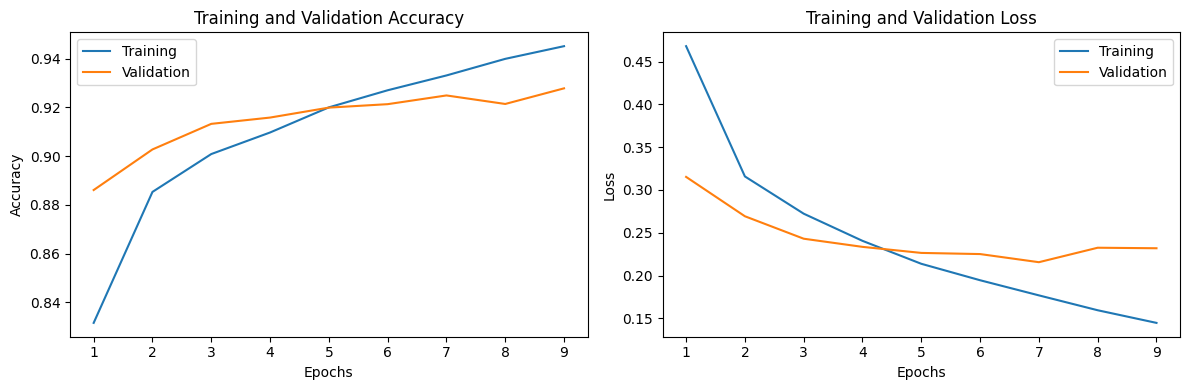

In [77]:
#To check the accuracy

epochs = range(1, len(history.history['loss']) + 1 )

plt.figure(figsize=(12,4))

#compare training and validation accuracy
plt.subplot(1,2,1)
plt.plot(epochs, history.history['accuracy'], label = "Training")
plt.plot(epochs, history.history['val_accuracy'], label = "Validation")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

#compare training and validation loss
plt.subplot(1,2,2)
plt.plot(epochs, history.history['loss'], label = "Training")
plt.plot(epochs, history.history['val_loss'], label = "Validation")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [81]:
#Evaluate on the held out test set without updating weights
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 0)

print(f"Test loss :{test_loss:.2f}")
print(f"Test Accuraacy : {test_acc * 100:.2f}")


Test loss :0.24
Test Accuraacy : 91.72


drive  sample_data
